In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import load
import net
import torch
import PDFM




In [3]:
fp = load.Fingerprint()

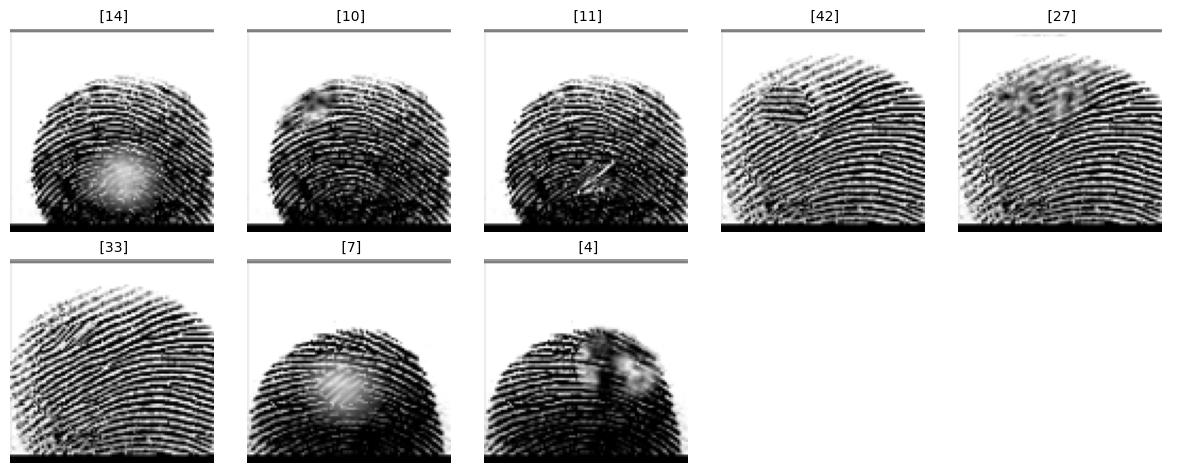

In [5]:
fp.viz(fp.data_np, index=(np.array([1,2,3,4,5,6,7,8])+10000))

### FM and refine

In [ ]:
FMclass = PDFM.PDFlowMatching(fp)
FMclass.train_FM_lambda0( lr=1e-5, save_name='FMt2', epoches = 50000, batch_size_N = 500, save_every=10000, init_path = './saved_model/FM_50000.pth')

### Seperately train the classifier $f_\phi$ (optional)

In [ ]:
FMclass = PDFM.PDFlowMatching(fp)
ckpt = torch.load('./saved_model/FM_50000.pth', weights_only=True)
FMclass.model.load_state_dict(ckpt)
FMclass.train_prob_model(batch_size = 500, lr = 1e-4, training_epochs = 50, init_ckpt_path = None,
                         inner_batch_size=None, inner_repeat_num=None, save_name = "pmodel4FM_50000.pth",
                         verbose = True, FM_step_num = None, t_val = -1)

### PDFM

In [ ]:
FMclass = PDFM.PDFlowMatching(fp)

FMclass.PDFMtrain( max_epoches_per_lambda=1000, batch_size_N=500, target_csrate = 0.99, PD_lr = 1, lr = 1e-5,
                  save_name = "PDFM",
                  FM_step_num=None,
                  para_lambda_init = None, PD_lr_decay = 0.9,
                  update_pmodel_every=10, init_ckpt_path='./saved_model/FM_50000.pth',  tval=-1,
                   patience = 50
        )

### Test constraint satisfaction rate and NLL


In [ ]:
# PDFM and FM model share the same structure, and they can share the regular FM Euler sampling
ckpt = torch.load('./saved_model/PDFM/PDFM_15_1p66.pth', weights_only=True)
# ckpt = torch.load('./saved_model/FMt2_10000.pth', weights_only=True)
FMclass.model.load_state_dict(ckpt)


feasibles = 0
rep=10
record = np.zeros(10)
sample_num = 1000
for i in range(rep):
    res = FMclass.sampler(sample_num) 
    a,b = fp.fingerprint_connected_component_oracle((res))
    feasibles += torch.sum(b<=50)
    print(torch.sum(b<=50))
    record[i] = torch.sum(b<=50).item()
    
print(feasibles/(rep*sample_num))

In [ ]:
NLL = 0
rep=10
# sample_num = 1000

for i in range(rep):
    tmp_samples = fp.get_samples(1000)
    a,b = fp.fingerprint_connected_component_oracle((tmp_samples))
    NLL+=FMclass.estimate_nll(tmp_samples[a][:500])/(96**2)
    print(NLL/(i+1))
    

### Visualization

In [ ]:
res = FMclass.sampler(100)
fp.viz(res, save_name = 'FM')